In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rcParams
from chemevo import evolution as evo
import astropy
from astropy.table import Table
from astropy.io import fits

params = {
   'axes.labelsize': 15,
   'font.size': 15,
   'legend.fontsize': 14,
   'xtick.minor.visible': True,
   'ytick.minor.visible': True,
   'xtick.labelsize': 15,
   'ytick.labelsize': 15,
   'text.usetex': True, #to use TeX in your labels
   'font.family':'serif',
   'axes.titlesize': 15,
   'xtick.direction': 'in',
   'ytick.direction': 'in',
   'xtick.top': True,
   'ytick.right': True,
   'xtick.major.size': 6,
   'xtick.minor.size': 3,
   'ytick.major.size': 6,
   'ytick.minor.size': 3
   }
rcParams.update(params)

colors = ["#0072B2", "#E69F00", "#009E73", "#D55E00", "#CC79A7", "#F0E442"]
linestyles = ['-', '--', ':', '-.']

In [17]:
import pandas as pd
from astropy.io import fits
from astropy.table import Table

def decode(df):
    """
    Decode DataFrame with byte strings into ordinary strings.
    """
    str_df = df.select_dtypes([object])
    str_df = str_df.stack().str.decode('utf-8').unstack()
    for col in str_df:
        df[col] = str_df[col]
    return df

def fitsrec_to_pandas(fits_rec):
    """
    Convert a FITS_rec object (from astropy.io.fits) to a pandas DataFrame.
    """
    # Convert FITS_rec to astropy Table first
    table = Table(fits_rec)
    
    # Filter out multidimensional columns
    cols = [name for name in table.colnames if len(table[name].shape) <= 1]
    
    # Convert to pandas DataFrame
    df = table[cols].to_pandas()
    
    # Decode byte strings
    df = decode(df)
    
    return df


In [26]:
with fits.open('astroNN_2proc_crossmatch.fits') as hdul:
    astronn_data = hdul[1].data
    twoprocess_data = hdul[2].data

highalpha = pd.read_csv("../highalpha.csv")
lowalpha = pd.read_csv("../lowalpha.csv")

data = fitsrec_to_pandas(astronn_data)

data['MN_O'] = data['MN_H'] - data['O_H']
data['FE_O'] = data['FE_H'] - data['O_H']
data['MN_MG'] = data['MN_H'] - data['MG_H']
data['FE_MG'] = data['FE_H'] - data['MG_H']
data['MG_FE'] = data['MG_H'] - data['FE_H']

pos_FE_H = data[(data['FE_H'] > 0)]
neg_FE_H = data[(data['FE_H'] < 0)]
data_high_alpha = pd.concat([pos_FE_H[(pos_FE_H['MG_FE'] > 0.12)], neg_FE_H[neg_FE_H['MG_FE'] > 0.12 - 0.13 * neg_FE_H['FE_H']]])
data_low_alpha = pd.concat([pos_FE_H[(pos_FE_H['MG_FE'] < 0.12)], neg_FE_H[neg_FE_H['MG_FE'] < 0.12 - 0.13 * neg_FE_H['FE_H']]])

/var/folders/g0/fl404sj151l2v9xcdkjz9fq80000gn/T/ipykernel_57592/706383163.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(bbox_to_anchor=[1,1])


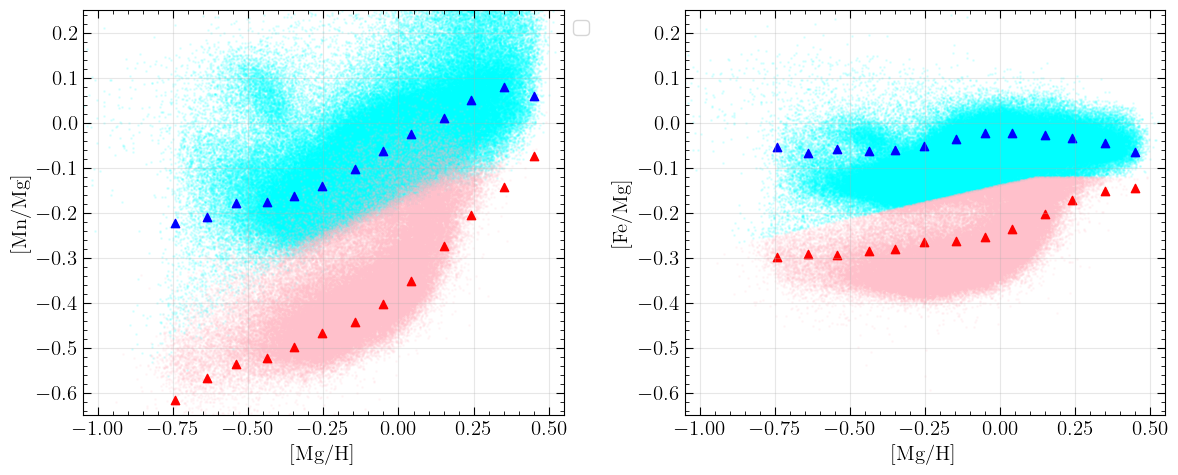

In [28]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.scatter(data_low_alpha['MG_H'], data_low_alpha['MN_MG'], alpha = 0.1, color = 'cyan', s = 1)
plt.scatter(data_high_alpha['MG_H'], data_high_alpha['MN_MG'], alpha = 0.1, color = 'pink', s = 1)

plt.scatter(highalpha['[Mg/H]'], highalpha['[Mn/Mg]'], marker='^', color = 'red', zorder=5)
plt.scatter(lowalpha['[Mg/H]'], lowalpha['[Mn/Mg]'], marker='^', color = 'blue', zorder=6)

plt.legend(bbox_to_anchor=[1,1])
plt.grid('True', alpha = 0.3)

plt.ylim(-0.65,0.25)
plt.xlabel('[Mg/H]')
plt.ylabel('[Mn/Mg]')
plt.xlim(-1.05,0.55)


plt.subplot(1,2,2)
plt.scatter(data_low_alpha['MG_H'], data_low_alpha['FE_MG'], alpha = 0.1, color = 'cyan', s = 1)
plt.scatter(data_high_alpha['MG_H'], data_high_alpha['FE_MG'], alpha = 0.1, color = 'pink', s = 1)

plt.scatter(highalpha['[Mg/H]'], highalpha['[Fe/Mg]'], marker='^', color = 'red')
plt.scatter(lowalpha['[Mg/H]'], lowalpha['[Fe/Mg]'], marker='^', color = 'blue')
plt.grid('True', alpha = 0.3)
plt.xlabel('[Mg/H]')
plt.ylabel('[Fe/Mg]')
plt.ylim(-0.65,0.25)
plt.xlim(-1.05,0.55)
plt.tight_layout()

# CONST SFRS

Everything same as mock_stars_W2024_params, just changed stars abundances

In [29]:
t_array = np.linspace(0.0001,14,int(1e3))
dt = t_array[1] - t_array[0]
print("dt = ", dt)
tau_sfh_def = 6 #Gyrs
m_g_array_exp_def = 1 * np.exp(-t_array/tau_sfh_def)
m_g_array_const = np.ones(len(t_array))

tau_stars_2024 = [0.6, 2.0, 6.0]
etas_2024 = [0, 0.6, 2.0]

gal1 = evo.Galaxy(t_array=t_array, m_g_array=m_g_array_const, tau_star=tau_stars_2024[0], eta = etas_2024[0])
gal2 = evo.Galaxy(t_array=t_array, m_g_array=m_g_array_const, tau_star=tau_stars_2024[1], eta = etas_2024[1])
gal3 = evo.Galaxy(t_array=t_array, m_g_array=m_g_array_const, tau_star=tau_stars_2024[2], eta = etas_2024[2])

dt =  0.014013913913913914


In [30]:
mdot_star_consts = []
mstars_consts = []

for taustar in tau_stars_2024:
    mstars_consts.append(m_g_array_const/taustar * dt)


cdf_mstars_const_1 = np.cumsum(mstars_consts[0])/np.sum(mstars_consts[0])
cdf_mstars_const_2 = np.cumsum(mstars_consts[1])/np.sum(mstars_consts[1])
cdf_mstars_const_3 = np.cumsum(mstars_consts[2])/np.sum(mstars_consts[2])

In [32]:
# 2. Define how many samples you want
n_samples = 1000
# 3. Generate uniform random numbers
u = np.random.rand(n_samples)
# 4. Perform the inverse sampling to get indices
sampled_indices_1 = np.searchsorted(cdf_mstars_const_1, u)
sampled_indices_2 = np.searchsorted(cdf_mstars_const_2, u)
sampled_indices_3 = np.searchsorted(cdf_mstars_const_3, u)

error_on_met = 0.05
gal1_df = pd.DataFrame(columns=['O_H', 'Fe_O', 'Mn_O'])
gal2_df = pd.DataFrame(columns=['O_H', 'Fe_O', 'Mn_O'])
gal3_df = pd.DataFrame(columns=['O_H', 'Fe_O', 'Mn_O'])

gal1_df['O_H'] = np.random.normal(loc=gal1.O_H[sampled_indices_1], scale = error_on_met, size=n_samples)
gal1_df['Fe_O'] = np.random.normal(loc=gal1.Fe_O[sampled_indices_1], scale = error_on_met, size=n_samples)
gal1_df['Mn_O'] = np.random.normal(loc=gal1.Mn_O[sampled_indices_1], scale = error_on_met, size=n_samples)

gal2_df['O_H'] = np.random.normal(loc=gal2.O_H[sampled_indices_2], scale = error_on_met, size=n_samples)
gal2_df['Fe_O'] = np.random.normal(loc=gal2.Fe_O[sampled_indices_2], scale = error_on_met, size=n_samples)
gal2_df['Mn_O'] = np.random.normal(loc=gal2.Mn_O[sampled_indices_2], scale = error_on_met, size=n_samples)

gal3_df['O_H'] = np.random.normal(loc=gal3.O_H[sampled_indices_3], scale = error_on_met, size=n_samples)
gal3_df['Fe_O'] = np.random.normal(loc=gal3.Fe_O[sampled_indices_3], scale = error_on_met, size=n_samples)
gal3_df['Mn_O'] = np.random.normal(loc=gal3.Mn_O[sampled_indices_3], scale = error_on_met, size=n_samples)

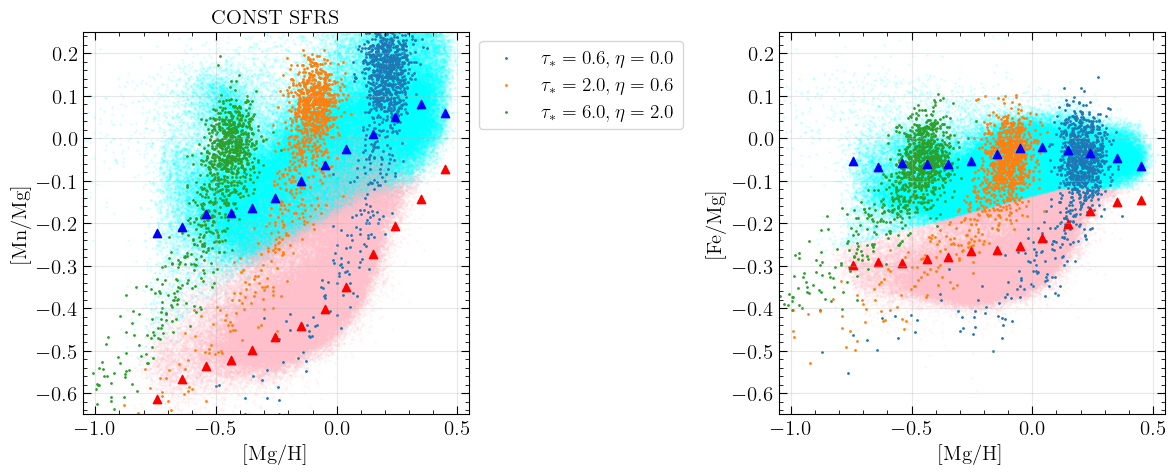

In [33]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.scatter(data_low_alpha['MG_H'], data_low_alpha['MN_MG'], alpha = 0.1, color = 'cyan', s = 1)
plt.scatter(data_high_alpha['MG_H'], data_high_alpha['MN_MG'], alpha = 0.1, color = 'pink', s = 1)
plt.scatter(highalpha['[Mg/H]'], highalpha['[Mn/Mg]'], marker='^', color = 'red', zorder=5)
plt.scatter(lowalpha['[Mg/H]'], lowalpha['[Mn/Mg]'], marker='^', color = 'blue', zorder=6)
plt.scatter(gal1_df['O_H'], gal1_df['Mn_O'], s = 1, label = rf'$\tau_* = {gal1.tau_star_arr[0]} , \eta = {gal1.eta_arr[0]} $')
plt.scatter(gal2_df['O_H'], gal2_df['Mn_O'], s = 1, label = rf'$\tau_* = {gal2.tau_star_arr[0]} , \eta = {gal2.eta_arr[0]} $')
plt.scatter(gal3_df['O_H'], gal3_df['Mn_O'], s = 1, label = rf'$\tau_* = {gal3.tau_star_arr[0]} , \eta = {gal3.eta_arr[0]} $')
plt.legend(bbox_to_anchor=[1,1])
plt.grid('True', alpha = 0.3)

plt.ylim(-0.65,0.25)
plt.title('CONST SFRS')
plt.xlabel('[Mg/H]')
plt.ylabel('[Mn/Mg]')
plt.xlim(-1.05,0.55)


plt.subplot(1,2,2)
plt.scatter(data_low_alpha['MG_H'], data_low_alpha['FE_MG'], alpha = 0.1, color = 'cyan', s = 1)
plt.scatter(data_high_alpha['MG_H'], data_high_alpha['FE_MG'], alpha = 0.1, color = 'pink', s = 1)
plt.scatter(gal1_df['O_H'], gal1_df['Fe_O'], s = 1)
plt.scatter(gal2_df['O_H'], gal2_df['Fe_O'], s = 1)
plt.scatter(gal3_df['O_H'], gal3_df['Fe_O'], s = 1)
plt.scatter(highalpha['[Mg/H]'], highalpha['[Fe/Mg]'], marker='^', color = 'red')
plt.scatter(lowalpha['[Mg/H]'], lowalpha['[Fe/Mg]'], marker='^', color = 'blue')
plt.grid('True', alpha = 0.3)
plt.xlabel('[Mg/H]')
plt.ylabel('[Fe/Mg]')
plt.ylim(-0.65,0.25)
plt.xlim(-1.05,0.55)
plt.tight_layout()